In [49]:
import pandas as pd
import os

In [53]:
# Define the directory containing CSV files
csv_dir = '../result/test/sctab/zeinab-classification-evals-20250409-manuscript-version/'

# Define expected columns
columns = ['accuracy', 'precision', 'recall', 'micro_f1', 'macro_f1', 'seed', 'dataset', 'ARtype', 'latent_dim', 'Atlas_cell_count']

# Initialize an empty list to store DataFrames
df_list = []

# Loop over all CSV files in the directory
for file in os.listdir(csv_dir):
    if file.endswith(".csv"):
        file_path = os.path.join(csv_dir, file)
        df_temp = pd.read_csv(file_path, usecols=columns)  # Load only relevant columns
        if 'ARtype_T' in file:
            df_temp["Balancing_method"] = 'AR'
        elif 'ARtype_F' in file:
            df_temp["Balancing_method"] = 'Standard'
        df_list.append(df_temp)  # Store DataFrame in the list

# Concatenate all DataFrames into one
df_original = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame(columns=columns)


In [54]:
df_original

,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,Balancing_method
0,0.637695,0.573488,0.479188,0.637695,0.503890,43,Kidney,F,64,100,Standard
1,0.691129,0.592652,0.466023,0.691129,0.491063,45,Heart,F,64,1,Standard
2,0.894000,0.861203,0.805490,0.894000,0.822117,44,Neurons,F,64,50000,Standard
3,0.525400,0.514631,0.395105,0.525400,0.413629,44,Neurons,F,64,1,Standard
4,0.725169,0.700423,0.514407,0.725169,0.558937,42,Heart,T,64,100,AR
...,...,...,...,...,...,...,...,...,...,...,...
205,0.662000,0.620020,0.539736,0.662000,0.553379,46,Neurons,F,64,10000,Standard
206,0.680519,0.610691,0.472418,0.680519,0.495772,42,Heart,F,64,1,Standard
207,0.895000,0.869542,0.812550,0.895000,0.825004,43,Neurons,F,64,50000,Standard
208,0.622343,0.536239,0.457606,0.622343,0.479288,46,Kidney,F,64,1,Standard


In [55]:
df_original.shape

(210, 11)

In [56]:
# Define the directory containing CSV files
csv_dir = '../result/test/sctab/scVI-classification-evals-balanced-data-4-7-26/'

# Initialize an empty list to store DataFrames
df_list = []

# Loop over all CSV files in the directory
for file in os.listdir(csv_dir):
    if file.endswith(".csv"):
        balancing_method = None
        if "class_balancing" in file:
            balancing_method = "Standard + Class Balance"
        elif "geometric_sketching" in file:
            balancing_method = "Standard + Geometric Sketching"
        else:
            continue
        file_path = os.path.join(csv_dir, file)
        df_temp = pd.read_csv(file_path, usecols=columns)  # Load only relevant columns
        df_temp["Balancing_method"] = balancing_method
        df_list.append(df_temp)  # Store DataFrame in the list

df_balanced = pd.concat(df_list, ignore_index=True) if df_list else pd.DataFrame(columns=columns)


In [57]:
print(df_balanced.shape)
print(df_balanced[df_balanced['seed'] == 42].shape[0])
print(df_balanced[df_balanced['seed'] == 43].shape[0])
print(df_balanced[df_balanced['seed'] == 44].shape[0])
print(df_balanced[df_balanced['seed'] == 45].shape[0])
print(df_balanced[df_balanced['seed'] == 46].shape[0])
# check if the number of rows for each seed is the same
assert df_balanced[df_balanced['seed'] == 42].shape[0] \
    == df_balanced[df_balanced['seed'] == 43].shape[0] \
    == df_balanced[df_balanced['seed'] == 44].shape[0] \
    == df_balanced[df_balanced['seed'] == 45].shape[0] \
    == df_balanced[df_balanced['seed'] == 46].shape[0]


(210, 11)
42
42
42
42
42


In [58]:
df_42 = df_balanced[df_balanced['seed'] == 42]
# sort df_42 based on Atlas_cell_count, Balancing_method 
df_42 = df_42.sort_values(by=['Atlas_cell_count', 'Balancing_method'])
df_42.head()

,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,Balancing_method
55,0.675012,0.665251,0.535913,0.675012,0.550464,42,Kidney,F,64,0,Standard + Class Balance
133,0.563400,0.553531,0.454893,0.563400,0.479655,42,Neurons,F,64,0,Standard + Class Balance
166,0.725464,0.660817,0.501281,0.725464,0.538315,42,Heart,F,64,0,Standard + Class Balance
22,0.584000,0.536777,0.461469,0.584000,0.480593,42,Neurons,F,64,0,Standard + Geometric Sketching
115,0.674303,0.675653,0.530731,0.674303,0.568464,42,Kidney,F,64,0,Standard + Geometric Sketching


In [59]:
df_43 = df_balanced[df_balanced['seed'] == 43]
# sort df_42 based on Atlas_cell_count, Balancing_method 
df_43 = df_43.sort_values(by=['Atlas_cell_count', 'Balancing_method'])
df_43.head()



,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,Balancing_method
12,0.712349,0.657711,0.448968,0.712349,0.479824,43,Heart,F,64,0,Standard + Class Balance
81,0.570000,0.592870,0.454734,0.570000,0.471236,43,Neurons,F,64,0,Standard + Class Balance
208,0.672178,0.606869,0.520040,0.672178,0.544507,43,Kidney,F,64,0,Standard + Class Balance
60,0.654700,0.624737,0.504764,0.654700,0.530737,43,Kidney,F,64,0,Standard + Geometric Sketching
85,0.700560,0.620824,0.461505,0.700560,0.496051,43,Heart,F,64,0,Standard + Geometric Sketching


In [60]:
# concat df_balanced and df_original
df = pd.concat([df_balanced, df_original])
df.head()

,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,Balancing_method
0,0.659424,0.623261,0.503874,0.659424,0.529943,44,Kidney,F,64,1,Standard + Geometric Sketching
1,0.836200,0.856164,0.757785,0.836200,0.783953,43,Neurons,F,64,100,Standard + Class Balance
2,0.690400,0.664987,0.569388,0.690400,0.587355,42,Neurons,F,64,50000,Standard + Geometric Sketching
3,0.672886,0.588614,0.509179,0.672886,0.526184,43,Kidney,F,64,10,Standard + Class Balance
4,0.645489,0.581552,0.479382,0.645489,0.496967,44,Kidney,F,64,1,Standard + Class Balance


In [61]:
# print number of rows for each Balancing_method
print(df['Balancing_method'].value_counts())


Balancing_method
Standard + Geometric Sketching    105
Standard + Class Balance          105
Standard                          105
AR                                105
Name: count, dtype: int64


In [62]:
# remove repeted rows
df = df.drop_duplicates()
df.head()

,accuracy,precision,recall,micro_f1,macro_f1,seed,dataset,ARtype,latent_dim,Atlas_cell_count,Balancing_method
0,0.659424,0.623261,0.503874,0.659424,0.529943,44,Kidney,F,64,1,Standard + Geometric Sketching
1,0.836200,0.856164,0.757785,0.836200,0.783953,43,Neurons,F,64,100,Standard + Class Balance
2,0.690400,0.664987,0.569388,0.690400,0.587355,42,Neurons,F,64,50000,Standard + Geometric Sketching
3,0.672886,0.588614,0.509179,0.672886,0.526184,43,Kidney,F,64,10,Standard + Class Balance
4,0.645489,0.581552,0.479382,0.645489,0.496967,44,Kidney,F,64,1,Standard + Class Balance


In [63]:
# assert if the number of rows for each seed is the same
assert df[df['seed'] == '42'].shape[0] \
    == df[df['seed'] == '43'].shape[0] \
    == df[df['seed'] == '44'].shape[0] \
    == df[df['seed'] == '45'].shape[0] \
    == df[df['seed'] == '46'].shape[0] 

In [64]:
df.columns = ['Accuracy', 'Precision', 'Recall', 'Micro F1 Score', 'Macro F1 Score', 'deed', 'dataset', 'ARtype', 'latent_dim', 'Atlas_cell_count', 'Balancing_method']

In [65]:
import pandas as pd

# Define metrics and target columns
metrics = ['Accuracy', 'Precision', 'Recall', 'Micro F1 Score', 'Macro F1 Score']
columns = ['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'Balancing_method']
plot_df_list = []

# Loop through each row in df
for index, row in df.iterrows():
    for metric in metrics:
        tmp_df = pd.DataFrame([[row['dataset'], metric, row[metric], row['ARtype'], row['Atlas_cell_count'], row['Balancing_method']]], 
                              columns=columns)
        plot_df_list.append(tmp_df)

# Concatenate all DataFrames
plot_df = pd.concat(plot_df_list, ignore_index=True) if plot_df_list else pd.DataFrame(columns=columns)


In [66]:
plot_df = plot_df.sort_values(by='Atlas_cell_count')
plot_df.head()

,dataset,metric,value,ARtype,Atlas_cell_count,Balancing_method
183,Neurons,Micro F1 Score,0.572800,F,0,Standard + Class Balance
210,Kidney,Accuracy,0.651630,F,0,Standard + Class Balance
755,Neurons,Accuracy,0.535200,F,0,Standard + Geometric Sketching
1450,Kidney,Accuracy,0.623760,F,0,Standard
1451,Kidney,Precision,0.591754,F,0,Standard


In [67]:
# change ARtype to AR and Naive
plot_df['ARtype'] = plot_df['ARtype'].replace({'T': 'AR', 'F': 'Standard'})

In [68]:
# print type of each column
print(plot_df.dtypes)
# print the unique values of each column
print(plot_df['dataset'].unique())
print(plot_df['metric'].unique())
print(plot_df['ARtype'].unique())
print(plot_df['Atlas_cell_count'].unique())

dataset              object
metric               object
value               float64
ARtype               object
Atlas_cell_count      int64
Balancing_method     object
dtype: object
['Neurons' 'Kidney' 'Heart']
['Micro F1 Score' 'Accuracy' 'Precision' 'Recall' 'Macro F1 Score']
['Standard' 'AR']
[    0     1    10   100  1000 10000 50000]


In [69]:
# convert object data type to string
plot_df['dataset'] = plot_df['dataset'].astype(str)
plot_df['metric'] = plot_df['metric'].astype(str)
plot_df['ARtype'] = plot_df['ARtype'].astype(str)
plot_df['Balancing_method'] = plot_df['Balancing_method'].astype(str)

In [76]:
plot_df

,dataset,metric,value,ARtype,Atlas_cell_count,Balancing_method
183,Neurons,Micro F1 Score,0.572800,Standard,0,Standard + Class Balance
210,Kidney,Accuracy,0.651630,Standard,0,Standard + Class Balance
755,Neurons,Accuracy,0.535200,Standard,0,Standard + Geometric Sketching
1450,Kidney,Accuracy,0.623760,Standard,0,Standard
1451,Kidney,Precision,0.591754,Standard,0,Standard
...,...,...,...,...,...,...
1816,Kidney,Precision,0.751115,Standard,50000,Standard
1815,Kidney,Accuracy,0.781530,Standard,50000,Standard
1814,Kidney,Macro F1 Score,0.787687,AR,50000,AR
1822,Heart,Recall,0.727139,Standard,50000,Standard


In [77]:
# write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and Naive using t-test
from scipy import stats
results = []
for dataset in plot_df['dataset'].unique():
    for metric in plot_df['metric'].unique():
        for atlas_cell_count in plot_df['Atlas_cell_count'].unique():
            ar_values = plot_df[(plot_df['dataset'] == dataset) & 
                                (plot_df['metric'] == metric) & 
                                (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
                                (plot_df['ARtype'] == 'AR') &
                                (plot_df['Balancing_method'] == 'AR')]['value']
            naive_values = plot_df[(plot_df['dataset'] == dataset) & 
                                   (plot_df['metric'] == metric) & 
                                   (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
                                   (plot_df['ARtype'] == 'Standard') &
                                   (plot_df['Balancing_method'] == 'Standard')]['value']
            if len(ar_values) > 1 and len(naive_values) > 1:
                t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                results.append([dataset, metric, atlas_cell_count, p_value])
            else:
                results.append([dataset, metric, atlas_cell_count, None])

In [78]:
results

[['Neurons', 'Micro F1 Score', 0, 0.00877249660297655],
 ['Neurons', 'Micro F1 Score', 1, 0.017972984125250828],
 ['Neurons', 'Micro F1 Score', 10, 0.09060399193258123],
 ['Neurons', 'Micro F1 Score', 100, 0.00013331849905281605],
 ['Neurons', 'Micro F1 Score', 1000, 1.9076343843530267e-07],
 ['Neurons', 'Micro F1 Score', 10000, 9.524849486074098e-07],
 ['Neurons', 'Micro F1 Score', 50000, 0.16196004449918802],
 ['Neurons', 'Accuracy', 0, 0.00877249660297655],
 ['Neurons', 'Accuracy', 1, 0.017972984125250828],
 ['Neurons', 'Accuracy', 10, 0.09060399193258123],
 ['Neurons', 'Accuracy', 100, 0.00013331849905281605],
 ['Neurons', 'Accuracy', 1000, 1.90763438435302e-07],
 ['Neurons', 'Accuracy', 10000, 9.524849486074049e-07],
 ['Neurons', 'Accuracy', 50000, 0.1619600444991913],
 ['Neurons', 'Precision', 0, 0.07974511224264476],
 ['Neurons', 'Precision', 1, 0.034566226020540325],
 ['Neurons', 'Precision', 10, 0.12052855842867131],
 ['Neurons', 'Precision', 100, 0.00010116200348757085],
 ['N

In [79]:
results

[['Neurons', 'Micro F1 Score', 0, 0.00877249660297655],
 ['Neurons', 'Micro F1 Score', 1, 0.017972984125250828],
 ['Neurons', 'Micro F1 Score', 10, 0.09060399193258123],
 ['Neurons', 'Micro F1 Score', 100, 0.00013331849905281605],
 ['Neurons', 'Micro F1 Score', 1000, 1.9076343843530267e-07],
 ['Neurons', 'Micro F1 Score', 10000, 9.524849486074098e-07],
 ['Neurons', 'Micro F1 Score', 50000, 0.16196004449918802],
 ['Neurons', 'Accuracy', 0, 0.00877249660297655],
 ['Neurons', 'Accuracy', 1, 0.017972984125250828],
 ['Neurons', 'Accuracy', 10, 0.09060399193258123],
 ['Neurons', 'Accuracy', 100, 0.00013331849905281605],
 ['Neurons', 'Accuracy', 1000, 1.90763438435302e-07],
 ['Neurons', 'Accuracy', 10000, 9.524849486074049e-07],
 ['Neurons', 'Accuracy', 50000, 0.1619600444991913],
 ['Neurons', 'Precision', 0, 0.07974511224264476],
 ['Neurons', 'Precision', 1, 0.034566226020540325],
 ['Neurons', 'Precision', 10, 0.12052855842867131],
 ['Neurons', 'Precision', 100, 0.00010116200348757085],
 ['N

In [80]:
# Create a DataFrame from the results
pval_df = pd.DataFrame(results, columns=['dataset', 'metric', 'Atlas_cell_count', 'p_value'])

# print the pval_df in the form of a latex table in scientific notation with 2 decimal points, separately for each dataset, with rows as metrics and columns as Atlas_cell_count, with dataseet in caption, colored by their p-value (green for p<0.05, yellow for p>=0.05)
for dataset in pval_df['dataset'].unique():
    subset = pval_df[pval_df['dataset'] == dataset]
    pivot_table = subset.pivot(index='metric', columns='Atlas_cell_count', values='p_value')
    def color_pval(val):
        if pd.isna(val):
            return ''
        elif val < 0.05:
            return 'background-color: green; color: white;'
        else:
            return 'background-color: yellow; color: black;'
    styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
    # latex_table = styled_table.to_latex(caption=f'P-values for {dataset}', label=f'tab:pvalues_{dataset}')
    # print(latex_table)

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/1670325654.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/1670325654.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/1670325654.py:15: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")


In [82]:
# convert results to a dataframe
results_df = pd.DataFrame(results)
results_df.columns = ['dataset', 'metric', 'Atlas_cell_count', 'p_value']

# plot results_df as a heatmap using seaborn for each dataset separately, with metric on the y-axis, Atlas_cell_count on the x-axis, and p-value < 0.05 light green and >= 0.05 light red, with annotated p-values in scientific notation
import seaborn as sns
import matplotlib.pyplot as plt

for dataset in results_df['dataset'].unique():
    pivot_df = results_df[results_df['dataset'] == dataset].pivot(index='metric', columns='Atlas_cell_count', values='p_value')
    display(pivot_df)
    # plt.figure(figsize=(10, 4))
    # sns.heatmap(pivot_df, annot=True, fmt=".1e", cmap=sns.color_palette(["green", "red"]), center=0.05, cbar_kws={'label': 'p-value'})
    # plt.title(f'P-values for {dataset}')
    # plt.ylabel('Metric')
    # plt.xlabel('Atlas Cell Count')
    # plt.tight_layout()
    # plt.show()

Atlas_cell_count,0,1,10,100,1000,10000,50000
metric,,,,,,,
Accuracy,0.008772,0.017973,0.090604,0.000133,1.907634e-07,9.524849e-07,0.161960
Macro F1 Score,0.005906,0.002334,0.171598,0.000348,9.476842e-07,3.990397e-06,0.576305
Micro F1 Score,0.008772,0.017973,0.090604,0.000133,1.907634e-07,9.524849e-07,0.161960
Precision,0.079745,0.034566,0.120529,0.000101,3.110904e-05,6.113207e-05,0.888557
Recall,0.006001,0.002778,0.186684,0.000224,5.547356e-07,1.508001e-06,0.524795


Atlas_cell_count,0,1,10,100,1000,10000,50000
metric,,,,,,,
Accuracy,0.041023,0.037192,0.093833,0.006753,0.000144,0.000016,0.000229
Macro F1 Score,0.021085,0.009161,0.011845,0.008743,0.000024,0.000013,0.000656
Micro F1 Score,0.041023,0.037192,0.093833,0.006753,0.000144,0.000016,0.000229
Precision,0.011360,0.000024,0.000023,0.001913,0.000055,0.000004,0.002670
Recall,0.050654,0.020362,0.078188,0.015661,0.000022,0.000017,0.000225


Atlas_cell_count,0,1,10,100,1000,10000,50000
metric,,,,,,,
Accuracy,0.001834,0.000160,0.015444,0.003956,2.732535e-07,7.704274e-07,0.000430
Macro F1 Score,0.026610,0.002616,0.011217,0.001177,2.548534e-06,1.229778e-04,0.003143
Micro F1 Score,0.001834,0.000160,0.015444,0.003956,2.732535e-07,7.704274e-07,0.000430
Precision,0.012510,0.009373,0.003143,0.006785,1.277265e-05,1.273025e-04,0.010582
Recall,0.048701,0.001966,0.023301,0.001276,3.665149e-06,7.858910e-05,0.006265


In [83]:
# print number of rows for each Balancing_method
print(plot_df['Balancing_method'].value_counts())


Balancing_method
Standard + Class Balance          525
Standard + Geometric Sketching    525
Standard                          525
AR                                525
Name: count, dtype: int64


In [84]:
# change column name Balancing_method to Balancing method
plot_df.rename(columns={'Balancing_method': 'Balancing method'}, inplace=True)
# change column name ARtype to Model
plot_df.rename(columns={'ARtype': 'Model'}, inplace=True)
plot_df.head()


,dataset,metric,value,Model,Atlas_cell_count,Balancing method
183,Neurons,Micro F1 Score,0.572800,Standard,0,Standard + Class Balance
210,Kidney,Accuracy,0.651630,Standard,0,Standard + Class Balance
755,Neurons,Accuracy,0.535200,Standard,0,Standard + Geometric Sketching
1450,Kidney,Accuracy,0.623760,Standard,0,Standard
1451,Kidney,Precision,0.591754,Standard,0,Standard


/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


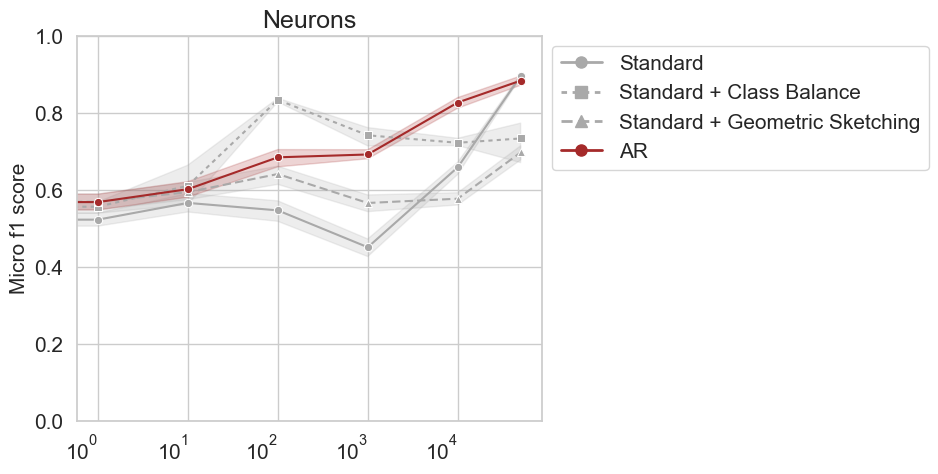

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


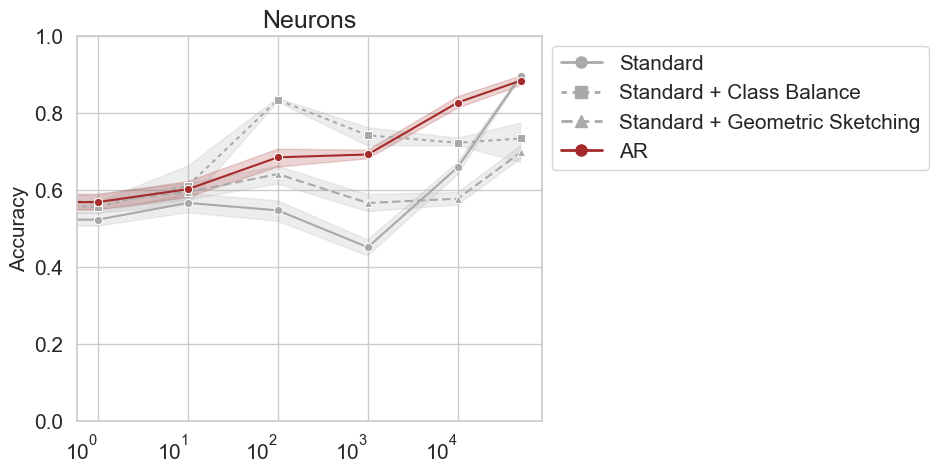

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


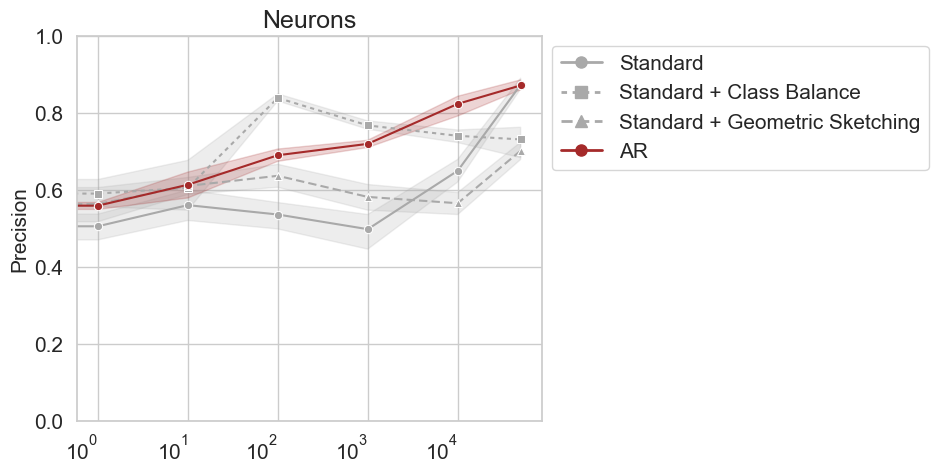

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


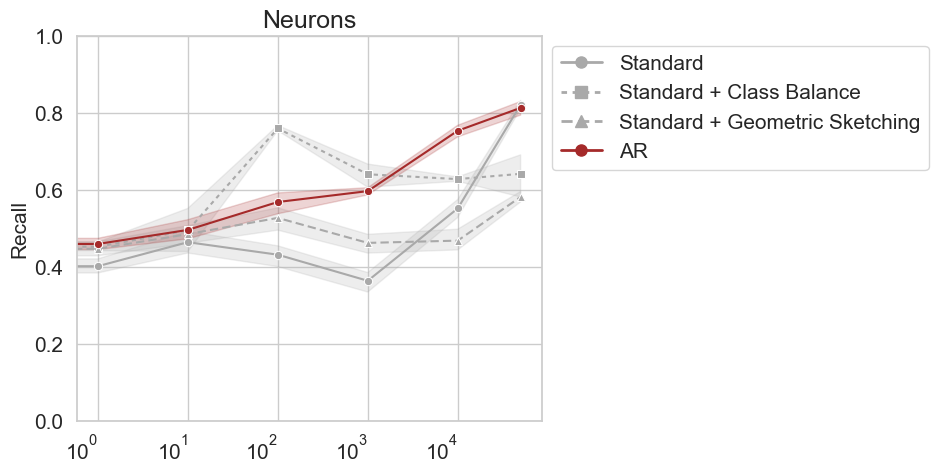

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


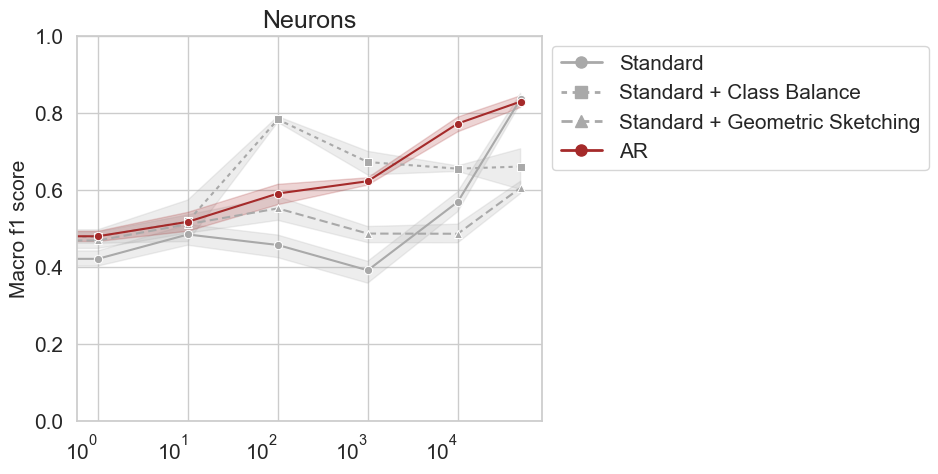

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


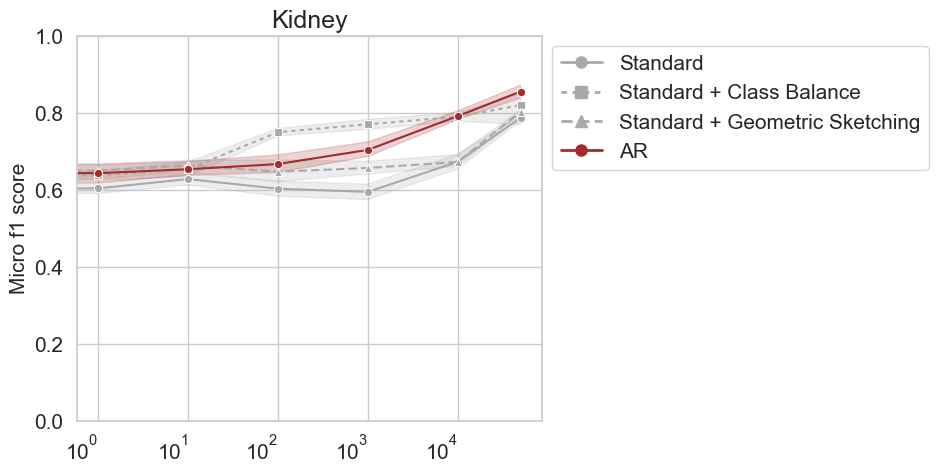

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


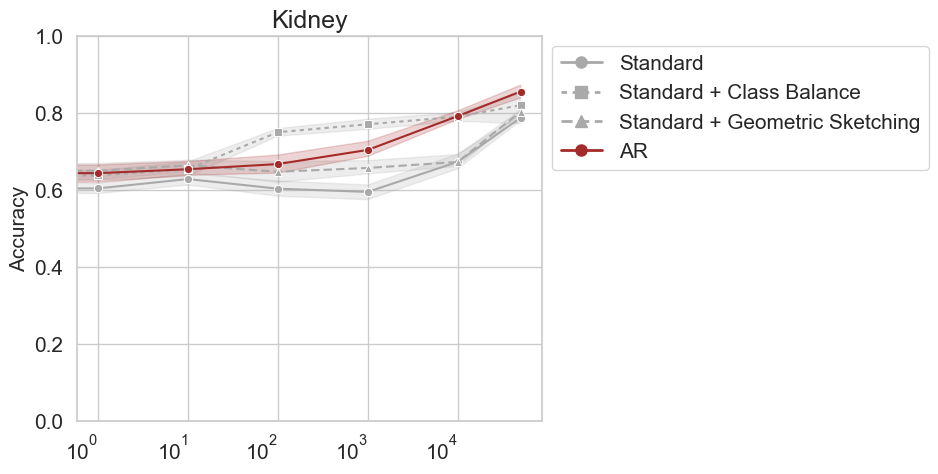

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


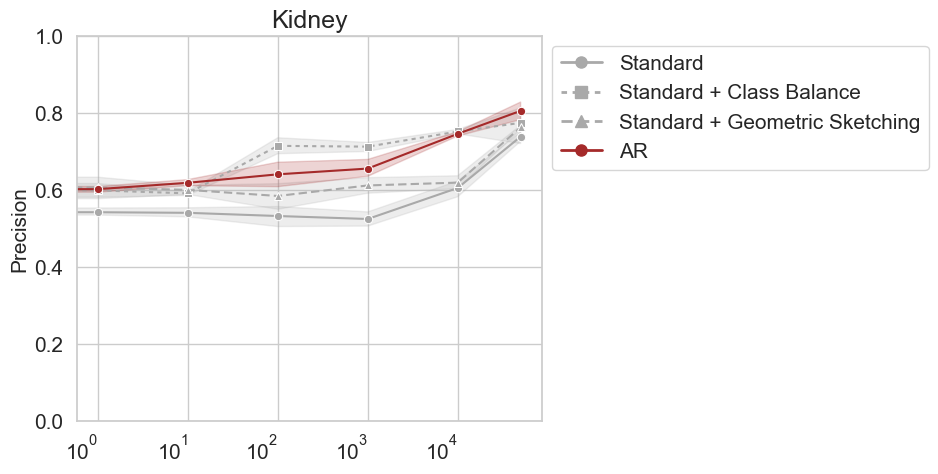

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


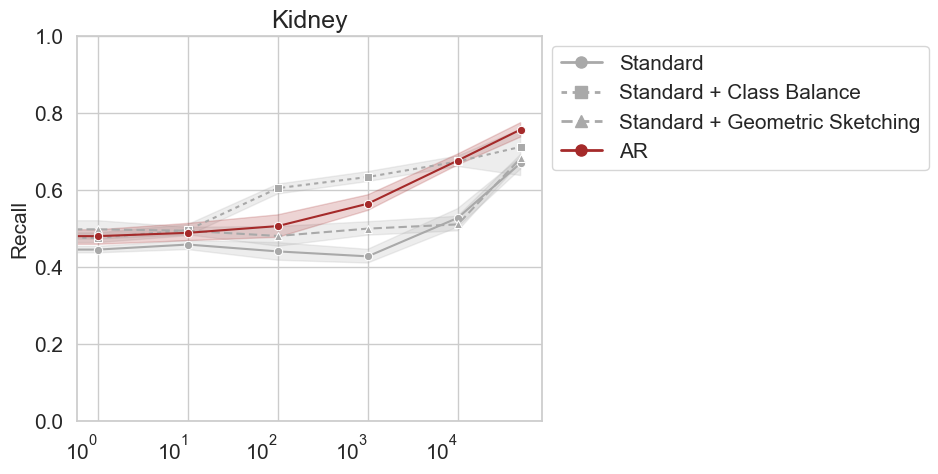

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


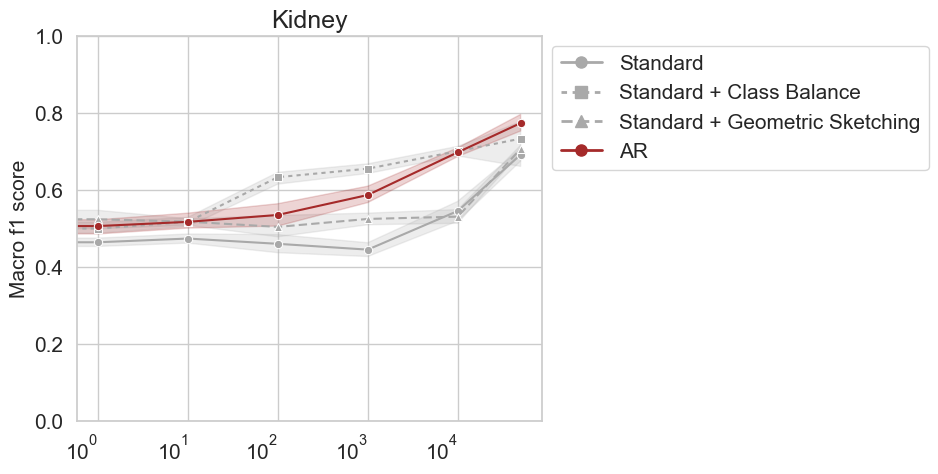

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


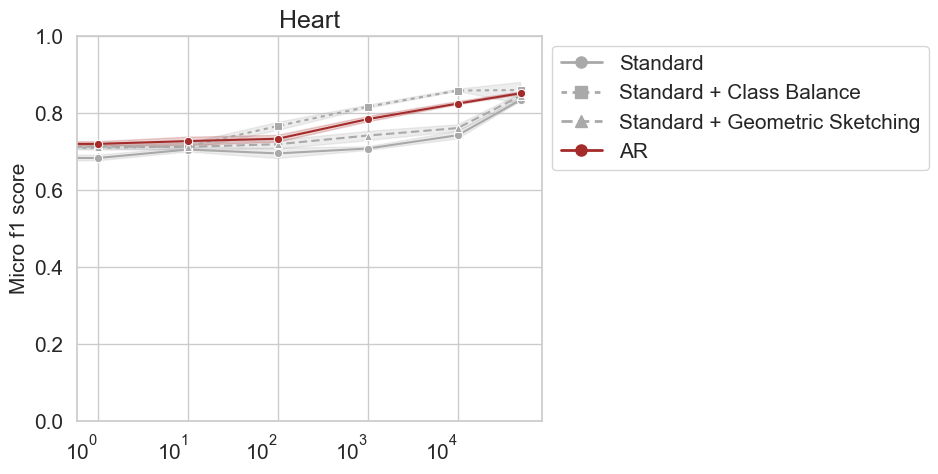

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


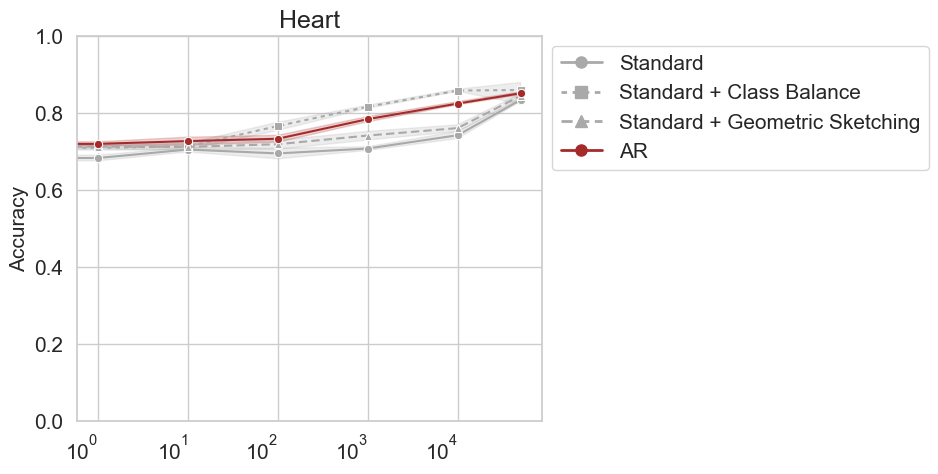

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


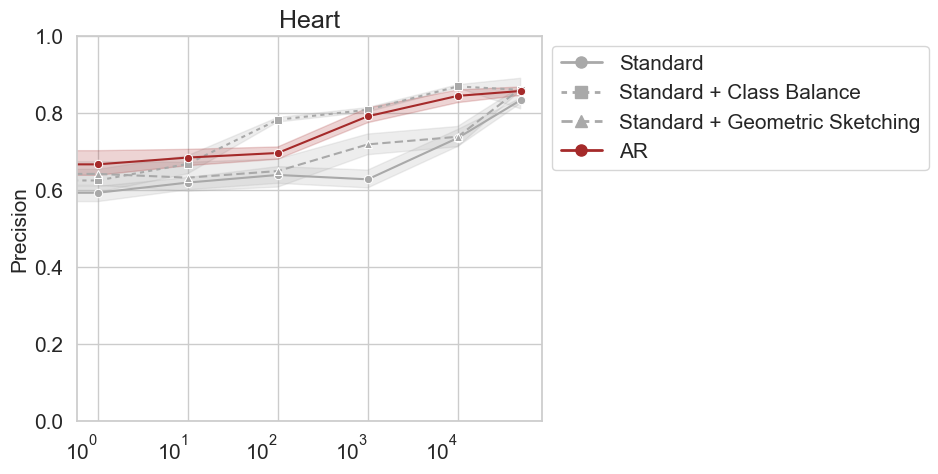

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


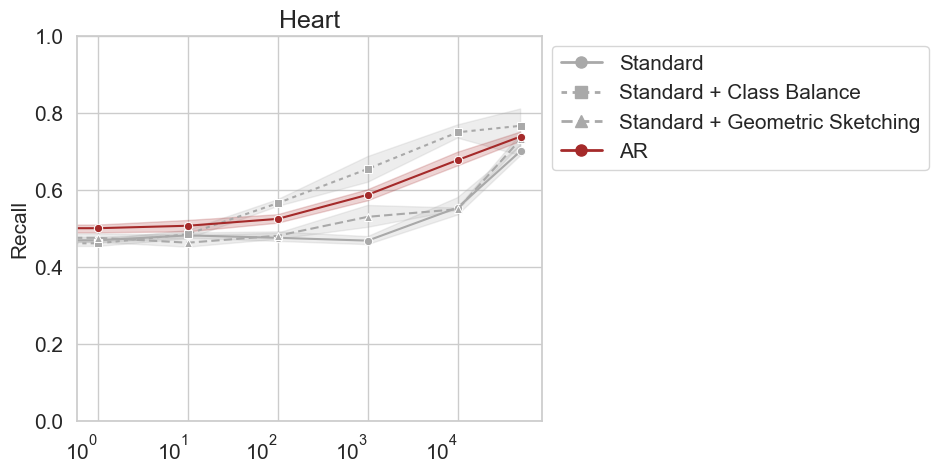

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/2845863132.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


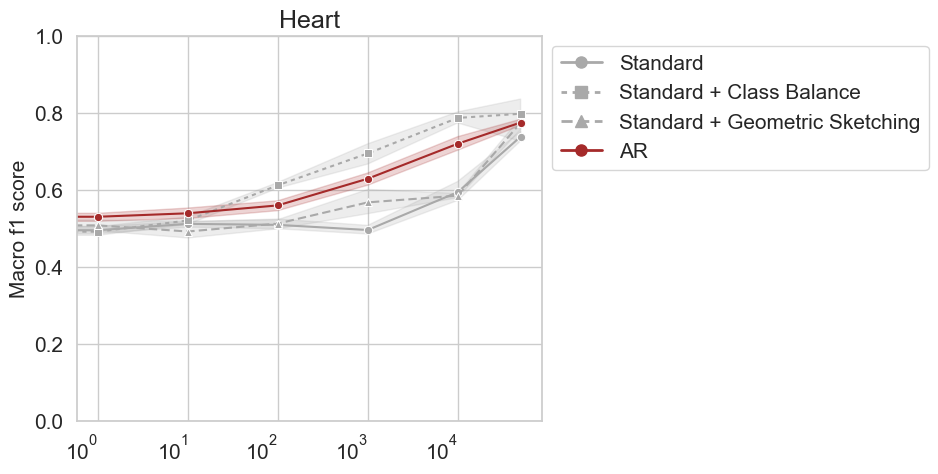

In [96]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Use this for lineplot color mapping by Model column, but styling/legend will match balancing method
palette = {
    'Standard': "darkgray",
    'AR': "brown"
}

balancing_order = [
    'Standard',
    'Standard + Class Balance',
    'Standard + Geometric Sketching',
    'AR'
]

markers = {
    'Standard': 'o',
    'Standard + Class Balance': 's',
    'Standard + Geometric Sketching': '^',
    'AR': 'o'
}

dashes = {
    'Standard': '',
    'Standard + Class Balance': (2, 2),
    'Standard + Geometric Sketching': (4, 2),
    'AR': ''
}

balancing_color = {
    'Standard': 'darkgray',
    'Standard + Class Balance': 'darkgray',
    'Standard + Geometric Sketching': 'darkgray',
    'AR': 'brown'
}

# For each dataset and metric
for dataset in plot_df['dataset'].unique():
    for metric in plot_df['metric'].unique():
        fig, axs = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")
        # Plotting
        g = sns.lineplot(
            data=plot_df[(plot_df['dataset'] == dataset) & (plot_df['metric'] == metric)],
            x="Atlas_cell_count",
            y="value",
            hue="Model",
            style="Balancing method",
            hue_order=['Standard', 'AR'],
            style_order=balancing_order,
            markers=markers,
            dashes=dashes,
            palette=palette,
        )
        g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')
        g.set_xlabel('')
        g.set_ylabel(metric.capitalize(), fontsize=15)
        g.set_title(dataset.capitalize(), fontsize=18)
        g.tick_params(axis='both', which='major', labelsize=15)
        g.tick_params(axis='both', which='minor', labelsize=15)
        g.set_xscale("log", base=10)

        # --- Custom legend for Balancing method with requested color, marker, dash ---
        legend_handles = []
        plotted_df = plot_df[(plot_df['dataset'] == dataset) & (plot_df['metric'] == metric)]
        added_labels = set()
        for method in balancing_order:
            # check if this method is present in data
            if method in plotted_df['Balancing method'].values or (method == 'AR' and (plotted_df['Model'] == 'AR').any()):
                legend_label = method
                legend_color = balancing_color[method]
                markerstyle = markers.get(method, 'o')
                dashstyle = dashes.get(method, "")
                # Only add once per label
                if legend_label not in added_labels:
                    added_labels.add(legend_label)
                    legend_handles.append(
                        Line2D(
                            [0], [0],
                            color=legend_color,
                            marker=markerstyle,
                            linestyle='-' if dashstyle == '' else (0, dashstyle),
                            label=legend_label,
                            markersize=8,
                            linewidth=2
                        )
                    )

        g.legend(
            handles=legend_handles,
            labels=[h.get_label() for h in legend_handles],
            loc='upper left',
            fontsize=15,
            bbox_to_anchor=(1, 1),
            title=None
        )

        g.set(ylim=(0, 1))
        plt.savefig(
            f'/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/figure/balanced_data_4-7-26/{dataset}_{metric}.png',
            dpi=600,
            bbox_inches='tight'
        )
        plt.show()
        # break


compute p-value between AR and class balancing

In [97]:
plot_df

,dataset,metric,value,Model,Atlas_cell_count,Balancing method
183,Neurons,Micro F1 Score,0.572800,Standard,0,Standard + Class Balance
210,Kidney,Accuracy,0.651630,Standard,0,Standard + Class Balance
755,Neurons,Accuracy,0.535200,Standard,0,Standard + Geometric Sketching
1450,Kidney,Accuracy,0.623760,Standard,0,Standard
1451,Kidney,Precision,0.591754,Standard,0,Standard
...,...,...,...,...,...,...
1816,Kidney,Precision,0.751115,Standard,50000,Standard
1815,Kidney,Accuracy,0.781530,Standard,50000,Standard
1814,Kidney,Macro F1 Score,0.787687,AR,50000,AR
1822,Heart,Recall,0.727139,Standard,50000,Standard


In [98]:
# write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and class balancing using t-test
from scipy import stats
results_class_balancing = pd.DataFrame(columns=['dataset', 'metric', 'Atlas_cell_count', 'p_value', 'better_method'])

for dataset in plot_df['dataset'].unique():
    for metric in plot_df['metric'].unique():
        for atlas_cell_count in plot_df['Atlas_cell_count'].unique():
            ar_values = plot_df[(plot_df['dataset'] == dataset) & 
                                (plot_df['metric'] == metric) & 
                                (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
                                (plot_df['Model'] == 'AR') &
                                (plot_df['Balancing method'] == 'AR')]['value']
            naive_values = plot_df[(plot_df['dataset'] == dataset) & 
                                   (plot_df['metric'] == metric) & 
                                   (plot_df['Atlas_cell_count'] == atlas_cell_count) & 
                                   (plot_df['Model'] == 'Standard') &
                                   (plot_df['Balancing method'] == 'Standard + Class Balance')]['value']
            better_method = 'Standard + Class Balance'
            if ar_values.mean() > naive_values.mean():
                better_method = 'AR'
            if len(ar_values) > 1 and len(naive_values) > 1:
                t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                results_class_balancing.loc[len(results_class_balancing)] = [dataset, metric, atlas_cell_count, p_value, better_method]
            else:
                results_class_balancing.loc[len(results_class_balancing)] = [dataset, metric, atlas_cell_count, None, better_method]

In [99]:
# display all rows of results_class_balancing for each dataset separately, only for metric=Micro F1 Score
results_class_balancing[results_class_balancing['metric'] == 'Micro F1 Score']

,dataset,metric,Atlas_cell_count,p_value,better_method
0,Neurons,Micro F1 Score,0,0.047850,AR
1,Neurons,Micro F1 Score,1,0.429546,AR
2,Neurons,Micro F1 Score,10,0.790375,Standard + Class Balance
3,Neurons,Micro F1 Score,100,0.000004,Standard + Class Balance
4,Neurons,Micro F1 Score,1000,0.014038,Standard + Class Balance
5,Neurons,Micro F1 Score,10000,0.000007,AR
6,Neurons,Micro F1 Score,50000,0.001463,AR
35,Kidney,Micro F1 Score,0,0.265985,Standard + Class Balance
36,Kidney,Micro F1 Score,1,0.720460,AR
37,Kidney,Micro F1 Score,10,0.992558,Standard + Class Balance


Generate plot for reconstruction error

In [103]:
import pickle
import os
import pandas as pd


df_original_reconstruction = pd.DataFrame(columns=['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'seed', 'Balancing_method'])
dir ='../result/test/sctab/zeinab-reconstruction-evals-20250409-manuscript-version/'
# loop over all files inside dir and read the pickle files
for file in os.listdir(dir):
    if file.endswith(".pkl") and 'Reconstruction_seed_' in file:
        # print(file)
        
        # extract the dataset name, ARtype, seed and Atlas_cell_count from the file name
        ARtype = file.split('_')[4]
        seed = file.split('_')[2]
        Atlas_cell_count = file.split('_')[11]
        print('ARtype:', ARtype)
        print('seed:', seed)
        print('Atlas_cell_count:', Atlas_cell_count)
    
        # Open the pickle file in read-binary mode
        with open(dir+file, "rb") as f:
            print(file)
            if 'ARtype_T' in file:
                balancing_method = 'AR'
            else:
                balancing_method = 'Standard'
            data = pickle.load(f)
            print(list(data.keys()))
            dict_keys = list(data.keys())
            for key in dict_keys:
                test_df = data[key]
                print(test_df.columns)
                mean_r2 = test_df['r2'].mean()
                mean_corr = test_df['correlation'].mean()
                df_original_reconstruction.loc[len(df_original_reconstruction)] = [key, 'correlation', mean_corr, ARtype, Atlas_cell_count, seed, balancing_method]
                df_original_reconstruction.loc[len(df_original_reconstruction)] = [key, 'r2', mean_r2, ARtype, Atlas_cell_count, seed, balancing_method]


ARtype: T
seed: 46
Atlas_cell_count: 1000
Reconstruction_seed_46_ARtype_T_latent_dim_64_Atlas_cell_count_1000_bloodbase_eval.pkl
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: F
seed: 45
Atlas_cell_count: 50000
Reconstruction_seed_45_ARtype_F_latent_dim_64_Atlas_cell_count_50000_bloodbase_eval.pkl
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: T
seed: 43
Atlas_cell_count: 10
Reconstruction_seed_43_ARtype_T_latent_dim_64_Atlas_cell_count_10_bloodbase_eval.pkl
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reco

In [104]:
df_original_reconstruction

,dataset,metric,value,ARtype,Atlas_cell_count,seed,Balancing_method
0,scTab_Heart_reconstruction,correlation,0.444208,T,1000,46,AR
1,scTab_Heart_reconstruction,r2,0.206483,T,1000,46,AR
2,scTab_Kidney_reconstruction,correlation,0.459010,T,1000,46,AR
3,scTab_Kidney_reconstruction,r2,0.218427,T,1000,46,AR
4,Neurons_reconstruction,correlation,0.779582,T,1000,46,AR
...,...,...,...,...,...,...,...
415,scTab_Heart_reconstruction,r2,0.097664,T,10,46,AR
416,scTab_Kidney_reconstruction,correlation,0.291562,T,10,46,AR
417,scTab_Kidney_reconstruction,r2,0.094802,T,10,46,AR
418,Neurons_reconstruction,correlation,0.640428,T,10,46,AR


In [105]:
## read the reconstruction evals for scvi models with balanced data
df_balanced = pd.DataFrame(columns=['dataset', 'metric', 'value', 'ARtype', 'Atlas_cell_count', 'seed', 'Balancing_method'])
dir ='../result/test/sctab/scVI-reconstruction-evals-balanced-data/'
# loop over all files inside dir and read the pickle files
for file in os.listdir(dir):
    if file.endswith(".pkl") and 'Reconstruction_seed_' in file:
        # print(file)
        balancing_method = None
        if "class_balancing" in file:
            balancing_method = "Standard + Class Balance"
        elif "geometric_sketching" in file:
            balancing_method = "Standard + Geometric Sketching"
        else:
            continue
        
        # extract the dataset name, ARtype, seed and Atlas_cell_count from the file name
        ARtype = file.split('_')[4]
        seed = file.split('_')[2]
        Atlas_cell_count = file.split('_')[11]
        print('ARtype:', ARtype)
        print('seed:', seed)
        print('Atlas_cell_count:', Atlas_cell_count)
    
        # Open the pickle file in read-binary mode
        with open(dir+file, "rb") as f:
            data = pickle.load(f)
            print(list(data.keys()))
            dict_keys = list(data.keys())
            for key in dict_keys:
                test_df = data[key]
                print(test_df.columns)
                mean_r2 = test_df['r2'].mean()
                mean_corr = test_df['correlation'].mean()
                df_balanced.loc[len(df_balanced)] = [key, 'correlation', mean_corr, ARtype, Atlas_cell_count, seed, balancing_method]
                df_balanced.loc[len(df_balanced)] = [key, 'r2', mean_r2, ARtype, Atlas_cell_count, seed, balancing_method]


ARtype: F
seed: 42
Atlas_cell_count: 1000
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: F
seed: 45
Atlas_cell_count: 100
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: F
seed: 45
Atlas_cell_count: 50000
['scTab_Heart_reconstruction', 'scTab_Kidney_reconstruction', 'Neurons_reconstruction']
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'cell_type'], dtype='object')
Index(['correlation', 'r2', 'supercluster_term'], dtype='object')
ARtype: F
seed: 43
Atlas_cell_count: 50000
['scTab_Heart_reconst

In [106]:
df_balanced

,dataset,metric,value,ARtype,Atlas_cell_count,seed,Balancing_method
0,scTab_Heart_reconstruction,correlation,0.383130,F,1000,42,Standard + Geometric Sketching
1,scTab_Heart_reconstruction,r2,0.155529,F,1000,42,Standard + Geometric Sketching
2,scTab_Kidney_reconstruction,correlation,0.417168,F,1000,42,Standard + Geometric Sketching
3,scTab_Kidney_reconstruction,r2,0.185099,F,1000,42,Standard + Geometric Sketching
4,Neurons_reconstruction,correlation,0.741350,F,1000,42,Standard + Geometric Sketching
...,...,...,...,...,...,...,...
415,scTab_Heart_reconstruction,r2,0.185977,F,100,46,Standard + Class Balance
416,scTab_Kidney_reconstruction,correlation,0.397724,F,100,46,Standard + Class Balance
417,scTab_Kidney_reconstruction,r2,0.166854,F,100,46,Standard + Class Balance
418,Neurons_reconstruction,correlation,0.804603,F,100,46,Standard + Class Balance


In [107]:
# concat df_original_reconstruction and df_balanced
df = pd.concat([df_original_reconstruction, df_balanced])
df
# include only rows with seed in [42, 43, 44, 45, 46]

,dataset,metric,value,ARtype,Atlas_cell_count,seed,Balancing_method
0,scTab_Heart_reconstruction,correlation,0.444208,T,1000,46,AR
1,scTab_Heart_reconstruction,r2,0.206483,T,1000,46,AR
2,scTab_Kidney_reconstruction,correlation,0.459010,T,1000,46,AR
3,scTab_Kidney_reconstruction,r2,0.218427,T,1000,46,AR
4,Neurons_reconstruction,correlation,0.779582,T,1000,46,AR
...,...,...,...,...,...,...,...
415,scTab_Heart_reconstruction,r2,0.185977,F,100,46,Standard + Class Balance
416,scTab_Kidney_reconstruction,correlation,0.397724,F,100,46,Standard + Class Balance
417,scTab_Kidney_reconstruction,r2,0.166854,F,100,46,Standard + Class Balance
418,Neurons_reconstruction,correlation,0.804603,F,100,46,Standard + Class Balance


In [108]:
# include only rows with seed in [42, 43, 44, 45, 46]
df = df[df['seed'].isin(['42', '43', '44', '45', '46'])]
print(df[df['ARtype'] == 'T'].shape[0])
print(df[df['ARtype'] == 'F'].shape[0])

print('df[df[seed] == 42].shape[0]:', df[df['seed'] == '42'].shape[0])
print('df[df[seed] == 43].shape[0]:', df[df['seed'] == '43'].shape[0])
print('df[df[seed] == 44].shape[0]:', df[df['seed'] == '44'].shape[0])
print('df[df[seed] == 45].shape[0]:', df[df['seed'] == '45'].shape[0])
print('df[df[seed] == 46].shape[0]:', df[df['seed'] == '46'].shape[0])

# print the number of rows for each Atlas_cell_count
print('Atlas_cell_count:', df['Atlas_cell_count'].unique())
# print the number of rows for each Atlas_cell_count=0,1,10,100,1000,10000,50000
print('Atlas_cell_count=0:', df[df['Atlas_cell_count'] == '0'].shape[0])
print('Atlas_cell_count=1:', df[df['Atlas_cell_count'] == '1'].shape[0])
print('Atlas_cell_count=10:', df[df['Atlas_cell_count'] == '10'].shape[0])
print('Atlas_cell_count=100:', df[df['Atlas_cell_count'] == '100'].shape[0])
print('Atlas_cell_count=1000:', df[df['Atlas_cell_count'] == '1000'].shape[0])
print('Atlas_cell_count=10000:', df[df['Atlas_cell_count'] == '10000'].shape[0])
print('Atlas_cell_count=50000:', df[df['Atlas_cell_count'] == '50000'].shape[0])


# assert df[df['ARtype'] == 'T'].shape[0] == df[df['ARtype'] == 'F'].shape[0]
# assert if the number of rows for each seed is the same
assert df[df['seed'] == '42'].shape[0] \
    == df[df['seed'] == '43'].shape[0] \
    == df[df['seed'] == '44'].shape[0] \
    == df[df['seed'] == '45'].shape[0] \
    == df[df['seed'] == '46'].shape[0] 
    
df.shape

210
630
df[df[seed] == 42].shape[0]: 168
df[df[seed] == 43].shape[0]: 168
df[df[seed] == 44].shape[0]: 168
df[df[seed] == 45].shape[0]: 168
df[df[seed] == 46].shape[0]: 168
Atlas_cell_count: ['1000' '50000' '10' '1' '0' '100' '10000']
Atlas_cell_count=0: 120
Atlas_cell_count=1: 120
Atlas_cell_count=10: 120
Atlas_cell_count=100: 120
Atlas_cell_count=1000: 120
Atlas_cell_count=10000: 120
Atlas_cell_count=50000: 120


(840, 7)

In [109]:
# if 'heart' in df.dataset.lower, change it to 'Heart', if 'kidney' in df.dataset.lower, change it to 'Kidney'
df['dataset'] = df['dataset'].apply(lambda x: 'Heart' if 'heart' in x.lower() else x)
df['dataset'] = df['dataset'].apply(lambda x: 'Kidney' if 'kidney' in x.lower() else x)
df['dataset'] = df['dataset'].apply(lambda x: 'Neurons' if x=='Neurons_reconstruction' else x)

In [110]:
# replace ARtype with Standard
df['ARtype'] = df['ARtype'].apply(lambda x: 'Standard' if x == 'F' else 'AR')

In [117]:
# write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and Standard using t-test
from scipy import stats
results = []

for dataset in df['dataset'].unique():
    for metric in df['metric'].unique():
        for atlas_cell_count in df['Atlas_cell_count'].unique():
            ar_values = df[(df['dataset'] == dataset) & 
                                (df['metric'] == metric) & 
                                (df['Atlas_cell_count'] == atlas_cell_count) & 
                                (df['ARtype'] == 'AR') &
                                (df['Balancing_method'] == 'AR')]['value']
            naive_values = df[(df['dataset'] == dataset) & 
                                   (df['metric'] == metric) & 
                                   (df['Atlas_cell_count'] == atlas_cell_count) & 
                                   (df['ARtype'] == 'Standard') &
                                   (df['Balancing_method'] == 'Standard')]['value']
            if len(ar_values) > 1 and len(naive_values) > 1:
                t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                results.append([dataset, metric, atlas_cell_count, p_value])
            else:
                results.append([dataset, metric, atlas_cell_count, None])

In [118]:
# convert results to a dataframe
results_df = pd.DataFrame(results)
results_df.columns = ['dataset', 'metric', 'Atlas_cell_count', 'p_value']
print('shape of results_df:', results_df.shape)
results_df.head()

shape of results_df: (42, 4)


,dataset,metric,Atlas_cell_count,p_value
0,Heart,correlation,1000,2.013934e-07
1,Heart,correlation,50000,2.454040e-06
2,Heart,correlation,10,4.275485e-05
3,Heart,correlation,1,3.971956e-05
4,Heart,correlation,0,2.078610e-05


In [119]:
# print the latex table of results_df, with dataset in caption, colored by their p-value (green for p<0.05, yellow for p>=0.05)
for dataset in results_df['dataset'].unique():
    subset = results_df[results_df['dataset'] == dataset]
    pivot_table = subset.pivot(index='metric', columns='Atlas_cell_count', values='p_value')
    def color_pval(val):
        if pd.isna(val):
            return ''
        elif val < 0.05:
            return 'background-color: green; color: white;'
        else:
            return 'background-color: yellow; color: black;'
    styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
    latex_table = styled_table.to_latex(caption=f'P-values for {dataset}', label=f'tab:pvalues_{dataset}')
    print(latex_table)

\begin{table}
\caption{P-values for Heart}
\label{tab:pvalues_Heart}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 1 & 10 & 100 & 1000 & 10000 & 50000 \\
metric &  &  &  &  &  &  &  \\
correlation & \background-colorgreen \colorwhite 2.08e-05 & \background-colorgreen \colorwhite 3.97e-05 & \background-colorgreen \colorwhite 4.28e-05 & \background-colorgreen \colorwhite 3.94e-09 & \background-colorgreen \colorwhite 2.01e-07 & \background-colorgreen \colorwhite 2.18e-11 & \background-colorgreen \colorwhite 2.45e-06 \\
r2 & \background-colorgreen \colorwhite 3.27e-04 & \background-colorgreen \colorwhite 3.56e-04 & \background-colorgreen \colorwhite 1.26e-04 & \background-colorgreen \colorwhite 9.91e-08 & \background-colorgreen \colorwhite 8.29e-07 & \background-colorgreen \colorwhite 7.25e-12 & \background-colorgreen \colorwhite 1.49e-06 \\
\end{tabular}
\end{table}

\begin{table}
\caption{P-values for Kidney}
\label{tab:pvalues_Kidney}
\begin{tabular}{lrrrrrrr}
Atlas_cell_count & 0 & 

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/63112505.py:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/63112505.py:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")
/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/63112505.py:12: FutureWarning: Styler.applymap has been deprecated. Use Styler.map instead.
  styled_table = pivot_table.style.applymap(color_pval).format(precision=2, formatter="{:.2e}")


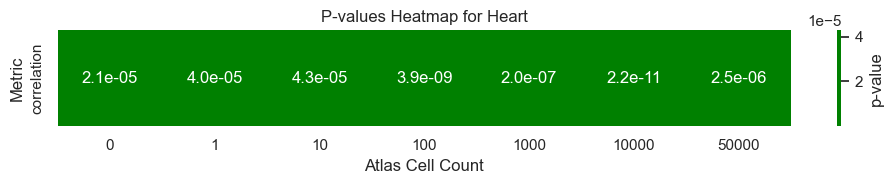

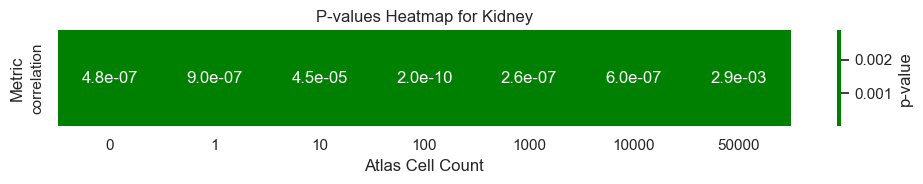

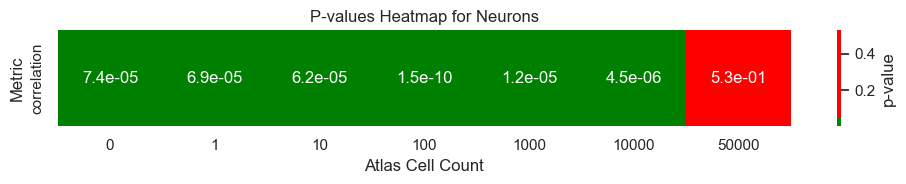

In [120]:

# plot heatmap of p-values for each dataset, where x axis is Atlas_cell_count, y axis is metric, and color is green if p-value < 0.05 else red
import seaborn as sns
import matplotlib.pyplot as plt
results_df = results_df[results_df['metric'].isin(['correlation'])]
for dataset in results_df['dataset'].unique():
    pivot_df = results_df[results_df['dataset'] == dataset].pivot(index='metric', columns='Atlas_cell_count', values='p_value')
    plt.figure(figsize=(10, 2))
    sns.heatmap(pivot_df, annot=True, fmt=".1e", cmap=sns.color_palette(["green", "red"]), center=0.05, cbar_kws={'label': 'p-value'})
    plt.title(f'P-values Heatmap for {dataset}')
    plt.xlabel('Atlas Cell Count')
    plt.ylabel('Metric')
    plt.axhline(y=-0.5, color='black', linewidth=2)  # Horizontal line at the top
    plt.axvline(x=-0.5, color='black', linewidth=2)  # Vertical line at the left
    plt.tight_layout()
    plt.show()


In [121]:
df

,dataset,metric,value,ARtype,Atlas_cell_count,seed,Balancing_method
0,Heart,correlation,0.444208,AR,1000,46,AR
1,Heart,r2,0.206483,AR,1000,46,AR
2,Kidney,correlation,0.459010,AR,1000,46,AR
3,Kidney,r2,0.218427,AR,1000,46,AR
4,Neurons,correlation,0.779582,AR,1000,46,AR
...,...,...,...,...,...,...,...
415,Heart,r2,0.185977,Standard,100,46,Standard + Class Balance
416,Kidney,correlation,0.397724,Standard,100,46,Standard + Class Balance
417,Kidney,r2,0.166854,Standard,100,46,Standard + Class Balance
418,Neurons,correlation,0.804603,Standard,100,46,Standard + Class Balance


/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/1420260377.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


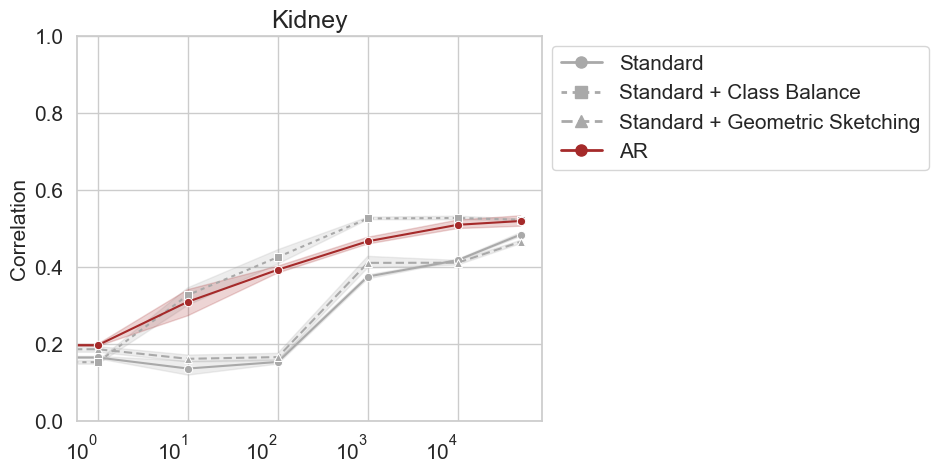

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/1420260377.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


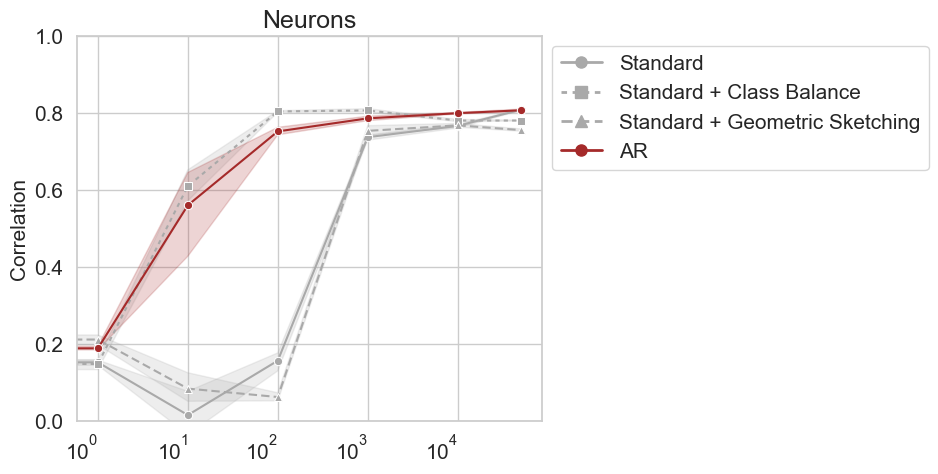

/var/folders/ct/rqgms94d3k9_mbqkrnng_f7h0000gn/T/ipykernel_7362/1420260377.py:57: UserWarning: FixedFormatter should only be used together with FixedLocator
  g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')


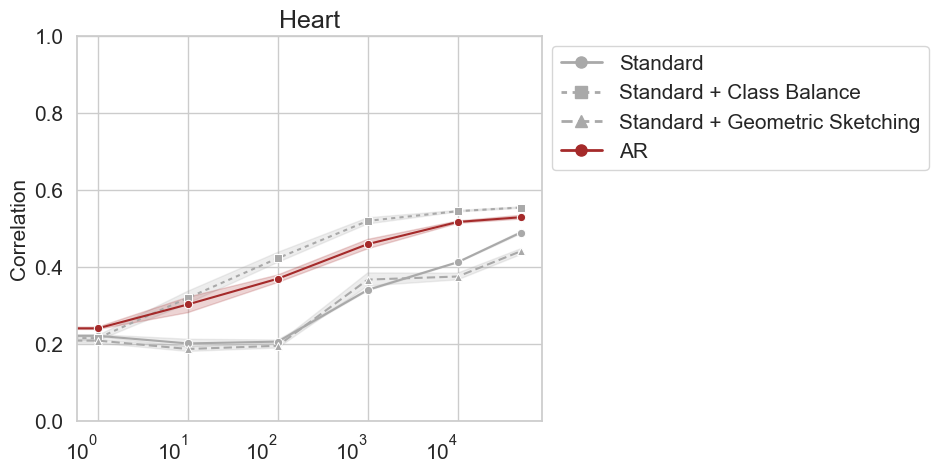

In [125]:
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# Ensure Atlas_cell_count is an int and sorted for plotting
df['Atlas_cell_count'] = df['Atlas_cell_count'].astype(int)
df = df.sort_values(by='Atlas_cell_count')

# Set all lines to darkgray except AR, which is brown
palette = {
    'Standard': "darkgray",
    'Standard + Class Balance': "darkgray",
    'Standard + Geometric Sketching': "darkgray",
    'AR': "brown"
}

balancing_order = [
    'Standard',
    'Standard + Class Balance',
    'Standard + Geometric Sketching',
    'AR'
]

markers = {
    'Standard': 'o',
    'Standard + Class Balance': 's',
    'Standard + Geometric Sketching': '^',
    'AR': 'o'
}

# Set dashes for line styles
dashes = {
    'Standard': '',
    'Standard + Class Balance': (2, 2),
    'Standard + Geometric Sketching': (4, 2),
    'AR': ''
}

for dataset in df['dataset'].unique():
    for metric in ['correlation']:
        fig, axs = plt.subplots(1, 1, figsize=(6, 5))
        sns.set_theme(style="whitegrid")

        g = sns.lineplot(
            data=df[(df['dataset'] == dataset) & (df['metric'] == metric)],
            x="Atlas_cell_count",
            y="value",
            hue="Balancing_method",
            style="Balancing_method",
            hue_order=balancing_order,
            style_order=balancing_order,
            markers=markers,
            dashes=dashes,
            palette=palette,
            legend=False # We'll handle legend manually
        )
        g.set_xticklabels(g.get_xticklabels(), horizontalalignment='right')
        g.set_xlabel('')
        g.set_ylabel(metric.capitalize(), fontsize=15)
        g.set_title(dataset.capitalize(), fontsize=18)
        g.tick_params(axis='both', which='major', labelsize=15)
        g.tick_params(axis='both', which='minor', labelsize=15)
        g.set_xscale("log", base=10)

        # --- Custom legend just for Balancing_method, matching color and dashes/markers ---
        legend_elements = [
            Line2D(
                [0], [0],
                color=palette[method],
                marker=markers[method],
                linestyle='-' if dashes[method] == '' else (0, dashes[method]),
                label=method,
                markersize=8,
                linewidth=2
            )
            for method in balancing_order
        ]
        g.legend(
            handles=legend_elements,
            title=None,
            loc='upper left',
            fontsize=15,
            title_fontsize=15,
            bbox_to_anchor=(1, 1)
        )

        g.set(ylim=(0, 1))

        plt.savefig(
            f'/Users/zeinab/Documents/MSR_internship/manuscript/nature_communications/rebuttal/new_results/scvi/figure/balanced_data_4-7-26/{dataset}_{metric}.png',
            dpi=600,
            bbox_inches='tight'
        )
        plt.show()

Compute pvalues between AR and class balancing

In [126]:
# write a piece of code that for each dataset, metric and Atlas_cell_count, it calculated the p-value between AR and Naive using t-test
from scipy import stats
results_class_balancing = pd.DataFrame(columns=['dataset', 'metric', 'Atlas_cell_count', 'p_value', 'better_method'])

for dataset in df['dataset'].unique():
    for metric in ['correlation']:
        for atlas_cell_count in df['Atlas_cell_count'].unique():
            ar_values = df[(df['dataset'] == dataset) & 
                                (df['metric'] == metric) & 
                                (df['Atlas_cell_count'] == atlas_cell_count) & 
                                (df['ARtype'] == 'AR') &
                                (df['Balancing_method'] == 'AR')]['value']
            naive_values = df[(df['dataset'] == dataset) & 
                                   (df['metric'] == metric) & 
                                   (df['Atlas_cell_count'] == atlas_cell_count) & 
                                   (df['ARtype'] == 'Standard') &
                                   (df['Balancing_method'] == 'Standard + Class Balance')]['value']
            better_method = 'Standard + Class Balance'
            if ar_values.mean() > naive_values.mean():
                better_method = 'AR'
            if len(ar_values) > 1 and len(naive_values) > 1:
                t_stat, p_value = stats.ttest_ind(ar_values, naive_values)
                results_class_balancing.loc[len(results_class_balancing)] = [dataset, metric, atlas_cell_count, p_value, better_method]
            else:
                results_class_balancing.loc[len(results_class_balancing)] = [dataset, metric, atlas_cell_count, None, better_method]

In [127]:
results_class_balancing

,dataset,metric,Atlas_cell_count,p_value,better_method
0,Kidney,correlation,0,1.906129e-07,AR
1,Kidney,correlation,1,4.760675e-07,AR
2,Kidney,correlation,10,4.886470e-01,Standard + Class Balance
3,Kidney,correlation,100,2.711378e-02,Standard + Class Balance
4,Kidney,correlation,1000,3.729433e-06,Standard + Class Balance
5,Kidney,correlation,10000,3.395414e-02,Standard + Class Balance
6,Kidney,correlation,50000,6.891337e-01,Standard + Class Balance
7,Neurons,correlation,0,7.392087e-06,AR
8,Neurons,correlation,1,9.133246e-04,AR
9,Neurons,correlation,10,4.880590e-01,Standard + Class Balance


In [128]:
results_class_balancing

,dataset,metric,Atlas_cell_count,p_value,better_method
0,Kidney,correlation,0,1.906129e-07,AR
1,Kidney,correlation,1,4.760675e-07,AR
2,Kidney,correlation,10,4.886470e-01,Standard + Class Balance
3,Kidney,correlation,100,2.711378e-02,Standard + Class Balance
4,Kidney,correlation,1000,3.729433e-06,Standard + Class Balance
5,Kidney,correlation,10000,3.395414e-02,Standard + Class Balance
6,Kidney,correlation,50000,6.891337e-01,Standard + Class Balance
7,Neurons,correlation,0,7.392087e-06,AR
8,Neurons,correlation,1,9.133246e-04,AR
9,Neurons,correlation,10,4.880590e-01,Standard + Class Balance
